# Online Food Delivery Customer Behavior Analysis and Prediction Using AI

## Project Overview

This project analyzes customer behavior in an online food delivery dataset
and develops machine-learning models to predict whether a customer will
order food online.

The project uses Python-based data analytics and machine learning techniques
including data cleaning, exploratory data analysis, feature preprocessing,
Logistic Regression, Random Forest classification, model evaluation,
prediction, and feature importance analysis.

## Technologies Used

- Python
- Pandas
- NumPy
- Matplotlib
- Seaborn
- Scikit-learn
- Jupyter Notebook

## Machine Learning Models

1. Logistic Regression
2. Random Forest Classifier

## Target Variable

`Output` — whether the customer orders food online (`Yes` / `No`)

In [ ]:
## Project Objectives

- Analyze the structure and quality of the online food delivery dataset.
- Clean duplicate and unnecessary data.
- Explore customer demographics and ordering behavior.
- Visualize relationships between customer attributes and online ordering.
- Prepare categorical and numerical features for machine learning.
- Train Logistic Regression and Random Forest classification models.
- Compare model performance using multiple evaluation metrics.
- Generate predictions for new customer records.
- Analyze Random Forest feature importance.
- Extract meaningful analytical insights from the dataset.

## Data Cleaning

The dataset initially contained 388 records and 14 columns.

During data-quality analysis, 103 exact duplicate records were identified.
These duplicate records were removed because retaining repeated identical
observations could give disproportionate weight to the same observation
during exploratory analysis and machine-learning training.

After duplicate removal, the dataset contains 285 unique records.

The unnecessary `Unnamed: 13` column was also removed because it duplicated
the `Output` variable.

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("Libraries imported successfully!")

Libraries imported successfully!


In [10]:
import os

print(os.listdir("Data"))

['.ipynb_checkpoints', 'online food delivery dataset.csv']


In [12]:
import pandas as pd

df = pd.read_csv("Data/online food delivery dataset.csv")

print("Dataset loaded successfully!")

Dataset loaded successfully!


In [13]:
df.head()

,Age,Gender,Marital Status,Occupation,Monthly Income,Educational Qualifications,Family size,Customer Type,latitude,longitude,Pin code,Output,Feedback,Unnamed: 13
0,20,Female,Single,Student,No Income,Post Graduate,4,Frequent,12.9766,77.5993,560001,Yes,Positive,Yes
1,24,Female,Single,Student,Below Rs.10000,Graduate,3,Regular,12.9770,77.5773,560009,Yes,Positive,Yes
2,22,Male,Single,Student,Below Rs.10000,Post Graduate,3,Regular,12.9551,77.6593,560017,Yes,Negative,Yes
3,22,Female,Single,Student,No Income,Graduate,6,Frequent,12.9473,77.5616,560019,Yes,Positive,Yes
4,22,Male,Single,Student,Below Rs.10000,Post Graduate,4,Frequent,12.9850,77.5533,560010,Yes,Positive,Yes


In [14]:
df.shape

(388, 14)

In [15]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 388 entries, 0 to 387
Data columns (total 14 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Age                         388 non-null    int64  
 1   Gender                      388 non-null    object 
 2   Marital Status              388 non-null    object 
 3   Occupation                  388 non-null    object 
 4   Monthly Income              388 non-null    object 
 5   Educational Qualifications  388 non-null    object 
 6   Family size                 388 non-null    int64  
 7   Customer Type               388 non-null    object 
 8   latitude                    388 non-null    float64
 9   longitude                   388 non-null    float64
 10  Pin code                    388 non-null    int64  
 11  Output                      388 non-null    object 
 12  Feedback                    388 non-null    object 
 13  Unnamed: 13                 388 non

In [16]:
df.isnull().sum()

Age                           0
Gender                        0
Marital Status                0
Occupation                    0
Monthly Income                0
Educational Qualifications    0
Family size                   0
Customer Type                 0
latitude                      0
longitude                     0
Pin code                      0
Output                        0
Feedback                      0
Unnamed: 13                   0
dtype: int64

In [17]:
df.duplicated().sum()

103

In [18]:
df.describe(include="all")

,Age,Gender,Marital Status,Occupation,Monthly Income,Educational Qualifications,Family size,Customer Type,latitude,longitude,Pin code,Output,Feedback,Unnamed: 13
count,388.000000,388,388,388,388,388,388.000000,388,388.000000,388.000000,388.000000,388,388,388
unique,NaN,2,3,4,5,5,NaN,3,NaN,NaN,NaN,2,2,2
top,NaN,Male,Single,Student,No Income,Graduate,NaN,Regular,NaN,NaN,NaN,Yes,Positive,Yes
freq,NaN,222,268,207,187,177,NaN,218,NaN,NaN,NaN,301,317,301
mean,24.628866,NaN,NaN,NaN,NaN,NaN,3.280928,NaN,12.972058,77.600160,560040.113402,NaN,NaN,NaN
std,2.975593,NaN,NaN,NaN,NaN,NaN,1.351025,NaN,0.044489,0.051354,31.399609,NaN,NaN,NaN
min,18.000000,NaN,NaN,NaN,NaN,NaN,1.000000,NaN,12.865200,77.484200,560001.000000,NaN,NaN,NaN
25%,23.000000,NaN,NaN,NaN,NaN,NaN,2.000000,NaN,12.936900,77.565275,560010.750000,NaN,NaN,NaN
50%,24.000000,NaN,NaN,NaN,NaN,NaN,3.000000,NaN,12.977000,77.592100,560033.500000,NaN,NaN,NaN
75%,26.000000,NaN,NaN,NaN,NaN,NaN,4.000000,NaN,12.997025,77.630900,560068.000000,NaN,NaN,NaN


In [19]:
print(df.columns.tolist())

['Age', 'Gender', 'Marital Status', 'Occupation', 'Monthly Income', 'Educational Qualifications', 'Family size', 'Customer Type', 'latitude', 'longitude', 'Pin code', 'Output', 'Feedback', 'Unnamed: 13']


In [20]:
df["Output"].equals(df["Unnamed: 13"])

True

In [29]:
print("Final dataset shape:", df.shape)
print("Missing values:", df.isnull().sum().sum())
print("Duplicate rows:", df.duplicated().sum())

Final dataset shape: (388, 13)
Missing values: 0
Duplicate rows: 103


In [30]:
df[df.duplicated(keep=False)].sort_values(by=list(df.columns)).head(20)

,Age,Gender,Marital Status,Occupation,Monthly Income,Educational Qualifications,Family size,Customer Type,latitude,longitude,Pin code,Output,Feedback
205,20,Male,Single,Student,No Income,Graduate,2,Regular,12.9261,77.6221,560034,Yes,Positive
332,20,Male,Single,Student,No Income,Graduate,2,Regular,12.9261,77.6221,560034,Yes,Positive
348,20,Male,Single,Student,No Income,Graduate,2,Regular,12.9261,77.6221,560034,Yes,Positive
226,21,Female,Single,Student,No Income,Post Graduate,3,Regular,12.9149,77.5635,560070,Yes,Positive
313,21,Female,Single,Student,No Income,Post Graduate,3,Regular,12.9149,77.5635,560070,Yes,Positive
212,21,Male,Single,Student,No Income,Graduate,2,Regular,13.0012,77.5995,560046,No,Negative
339,21,Male,Single,Student,No Income,Graduate,2,Regular,13.0012,77.5995,560046,No,Negative
13,21,Male,Single,Student,No Income,Graduate,4,Frequent,12.9770,77.5773,560009,Yes,Positive
77,21,Male,Single,Student,No Income,Graduate,4,Frequent,12.9770,77.5773,560009,Yes,Positive
231,21,Male,Single,Student,No Income,Graduate,5,Frequent,12.9783,77.6408,560038,Yes,Positive


In [31]:
print("Total rows:", len(df))
print("Duplicate rows:", df.duplicated().sum())
print("Unique rows:", df.drop_duplicates().shape[0])

Total rows: 388
Duplicate rows: 103
Unique rows: 285


In [32]:
df[df.duplicated(keep=False)].sort_values(by=list(df.columns)).head(20)

,Age,Gender,Marital Status,Occupation,Monthly Income,Educational Qualifications,Family size,Customer Type,latitude,longitude,Pin code,Output,Feedback
205,20,Male,Single,Student,No Income,Graduate,2,Regular,12.9261,77.6221,560034,Yes,Positive
332,20,Male,Single,Student,No Income,Graduate,2,Regular,12.9261,77.6221,560034,Yes,Positive
348,20,Male,Single,Student,No Income,Graduate,2,Regular,12.9261,77.6221,560034,Yes,Positive
226,21,Female,Single,Student,No Income,Post Graduate,3,Regular,12.9149,77.5635,560070,Yes,Positive
313,21,Female,Single,Student,No Income,Post Graduate,3,Regular,12.9149,77.5635,560070,Yes,Positive
212,21,Male,Single,Student,No Income,Graduate,2,Regular,13.0012,77.5995,560046,No,Negative
339,21,Male,Single,Student,No Income,Graduate,2,Regular,13.0012,77.5995,560046,No,Negative
13,21,Male,Single,Student,No Income,Graduate,4,Frequent,12.9770,77.5773,560009,Yes,Positive
77,21,Male,Single,Student,No Income,Graduate,4,Frequent,12.9770,77.5773,560009,Yes,Positive
231,21,Male,Single,Student,No Income,Graduate,5,Frequent,12.9783,77.6408,560038,Yes,Positive


df.value_counts().head(15)

In [34]:
print("Rows after removing duplicates:", len(df))
print("Remaining duplicates:", df.duplicated().sum())

Rows after removing duplicates: 388
Remaining duplicates: 103


In [35]:
df = df.drop_duplicates().reset_index(drop=True)

In [36]:
print("Rows after removing duplicates:", len(df))
print("Duplicate rows remaining:", df.duplicated().sum())

Rows after removing duplicates: 285
Duplicate rows remaining: 0


In [27]:
for col in categorical_columns:
    print("\n" + col)
    print(df[col].unique())


Gender
['Female' 'Male']

Marital Status
['Single' 'Married' 'Prefer not to say']

Occupation
['Student' 'Employee' 'Self Employeed' 'House wife']

Monthly Income
['No Income' 'Below Rs.10000' 'More than 50000' '10001 to 25000'
 '25001 to 50000']

Educational Qualifications
['Post Graduate' 'Graduate' 'Ph.D' 'Uneducated' 'School']

Customer Type
['Frequent' 'Regular' 'New']

Output
['Yes' 'No']

Feedback
['Positive' 'Negative']


In [28]:
df.isnull().sum()

Age                           0
Gender                        0
Marital Status                0
Occupation                    0
Monthly Income                0
Educational Qualifications    0
Family size                   0
Customer Type                 0
latitude                      0
longitude                     0
Pin code                      0
Output                        0
Feedback                      0
dtype: int64

In [38]:
print(df["Output"].value_counts())

Output
Yes    217
No      68
Name: count, dtype: int64


In [39]:
print(df["Output"].value_counts(normalize=True) * 100)

Output
Yes    76.140351
No     23.859649
Name: proportion, dtype: float64


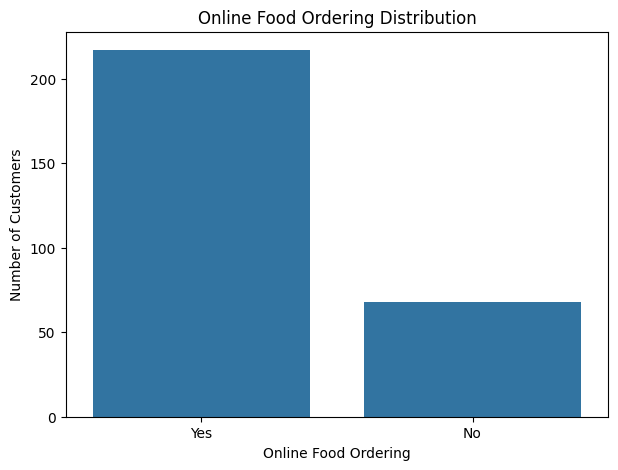

In [40]:
plt.figure(figsize=(7, 5))

sns.countplot(data=df, x="Output")

plt.title("Online Food Ordering Distribution")
plt.xlabel("Online Food Ordering")
plt.ylabel("Number of Customers")

plt.show()

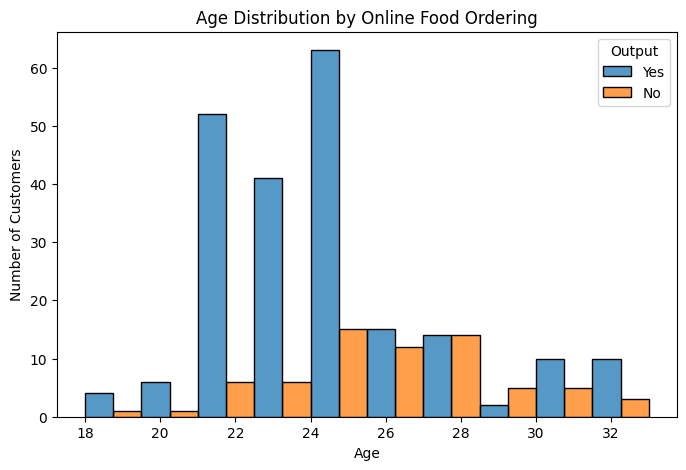

In [41]:
plt.figure(figsize=(8, 5))

sns.histplot(
    data=df,
    x="Age",
    hue="Output",
    bins=10,
    multiple="dodge"
)

plt.title("Age Distribution by Online Food Ordering")
plt.xlabel("Age")
plt.ylabel("Number of Customers")

plt.show()

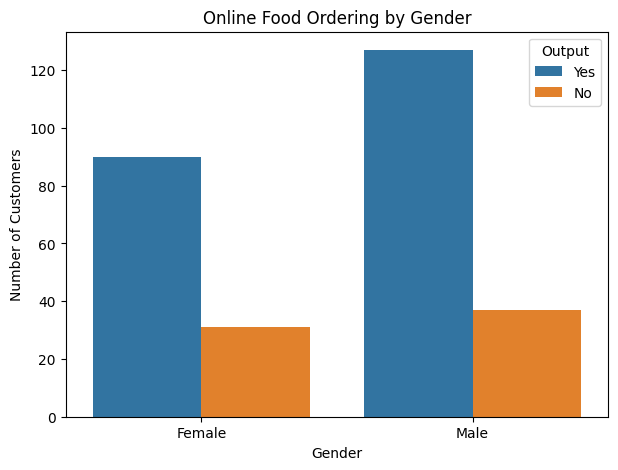

In [42]:
plt.figure(figsize=(7, 5))

sns.countplot(
    data=df,
    x="Gender",
    hue="Output"
)

plt.title("Online Food Ordering by Gender")
plt.xlabel("Gender")
plt.ylabel("Number of Customers")

plt.show()

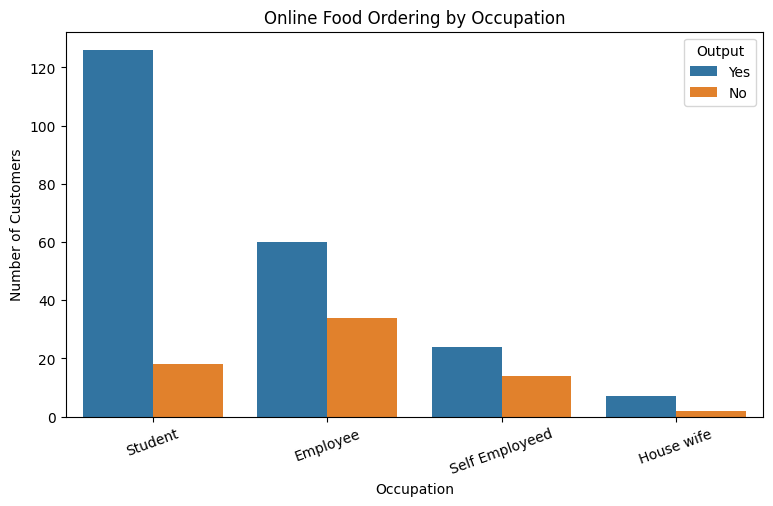

In [43]:
plt.figure(figsize=(9, 5))

sns.countplot(
    data=df,
    x="Occupation",
    hue="Output"
)

plt.title("Online Food Ordering by Occupation")
plt.xlabel("Occupation")
plt.ylabel("Number of Customers")
plt.xticks(rotation=20)

plt.show()

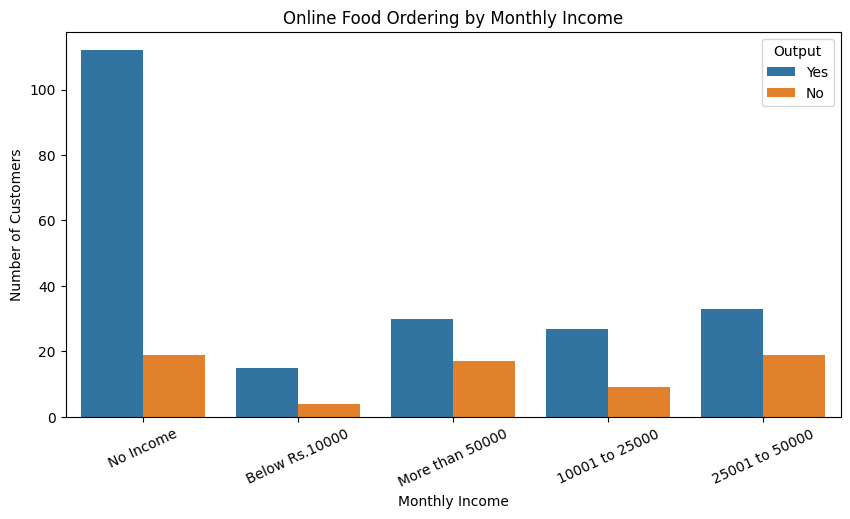

In [44]:
plt.figure(figsize=(10, 5))

sns.countplot(
    data=df,
    x="Monthly Income",
    hue="Output"
)

plt.title("Online Food Ordering by Monthly Income")
plt.xlabel("Monthly Income")
plt.ylabel("Number of Customers")
plt.xticks(rotation=25)

plt.show()

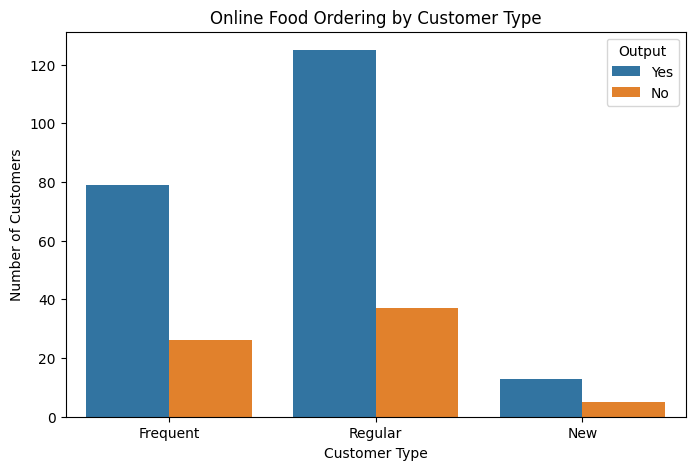

In [45]:
plt.figure(figsize=(8, 5))

sns.countplot(
    data=df,
    x="Customer Type",
    hue="Output"
)

plt.title("Online Food Ordering by Customer Type")
plt.xlabel("Customer Type")
plt.ylabel("Number of Customers")

plt.show()

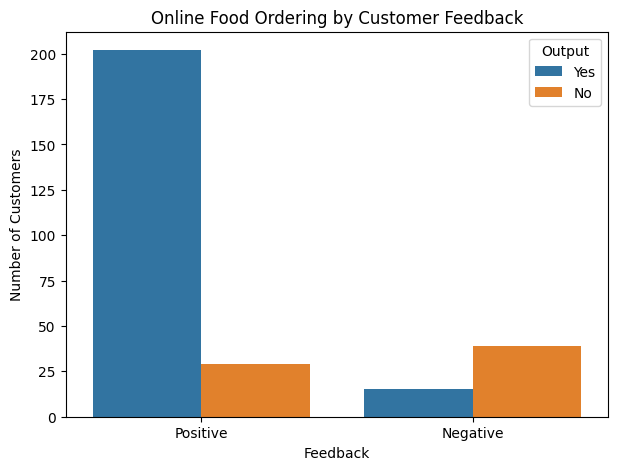

In [46]:
plt.figure(figsize=(7, 5))

sns.countplot(
    data=df,
    x="Feedback",
    hue="Output"
)

plt.title("Online Food Ordering by Customer Feedback")
plt.xlabel("Feedback")
plt.ylabel("Number of Customers")

plt.show()

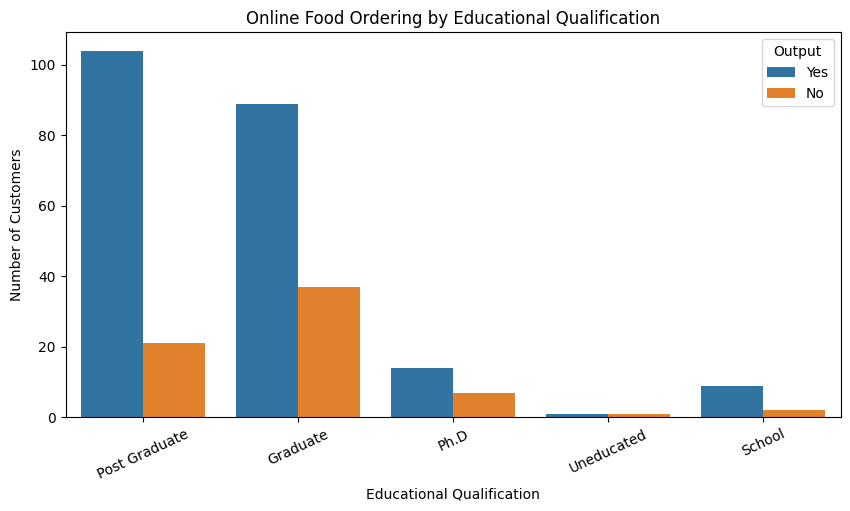

In [47]:
plt.figure(figsize=(10, 5))

sns.countplot(
    data=df,
    x="Educational Qualifications",
    hue="Output"
)

plt.title("Online Food Ordering by Educational Qualification")
plt.xlabel("Educational Qualification")
plt.ylabel("Number of Customers")
plt.xticks(rotation=25)

plt.show()

## Feature Engineering and Machine Learning Preparation

The `Output` column is selected as the target variable for binary classification.
The remaining customer attributes are used as input features.

Categorical variables will be encoded using One-Hot Encoding, while numerical
variables will be passed through without transformation.

In [49]:
# Separate features and target

X = df.drop(columns=["Output"])
y = df["Output"]

print("Feature shape:", X.shape)
print("Target shape:", y.shape)
print("\nTarget classes:")
print(y.value_counts())

Feature shape: (285, 12)
Target shape: (285,)

Target classes:
Output
Yes    217
No      68
Name: count, dtype: int64


In [50]:
categorical_features = X.select_dtypes(include=["object"]).columns.tolist()
numeric_features = X.select_dtypes(include=["int64", "float64"]).columns.tolist()

print("Categorical Features:")
print(categorical_features)

print("\nNumerical Features:")
print(numeric_features)

Categorical Features:
['Gender', 'Marital Status', 'Occupation', 'Monthly Income', 'Educational Qualifications', 'Customer Type', 'Feedback']

Numerical Features:
['Age', 'Family size', 'latitude', 'longitude', 'Pin code']


In [51]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Training samples: 228
Testing samples: 57


In [52]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

preprocessor = ColumnTransformer(
    transformers=[
        ("categorical", OneHotEncoder(handle_unknown="ignore"), categorical_features),
        ("numeric", "passthrough", numeric_features)
    ]
)

print("Preprocessing pipeline created successfully.")

Preprocessing pipeline created successfully.


## Machine Learning Model 1: Logistic Regression

Logistic Regression is used as a baseline classification model to predict
whether a customer will order food online.

In [53]:
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, classification_report

logistic_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", LogisticRegression(max_iter=1000))
    ]
)

logistic_model.fit(X_train, y_train)

y_pred_lr = logistic_model.predict(X_test)

print("Logistic Regression Accuracy:",
      accuracy_score(y_test, y_pred_lr))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_lr))

Logistic Regression Accuracy: 0.8421052631578947

Classification Report:
              precision    recall  f1-score   support

          No       0.73      0.57      0.64        14
         Yes       0.87      0.93      0.90        43

    accuracy                           0.84        57
   macro avg       0.80      0.75      0.77        57
weighted avg       0.83      0.84      0.84        57



## Machine Learning Model 2: Random Forest

Random Forest is an ensemble classification algorithm that combines
multiple decision trees to improve predictive performance and reduce
overfitting compared with a single decision tree.

In [54]:
from sklearn.ensemble import RandomForestClassifier

rf_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", RandomForestClassifier(
            n_estimators=200,
            random_state=42
        ))
    ]
)

rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

print("Random Forest Accuracy:",
      accuracy_score(y_test, y_pred_rf))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf))

Random Forest Accuracy: 0.8421052631578947

Classification Report:
              precision    recall  f1-score   support

          No       0.73      0.57      0.64        14
         Yes       0.87      0.93      0.90        43

    accuracy                           0.84        57
   macro avg       0.80      0.75      0.77        57
weighted avg       0.83      0.84      0.84        57



In [55]:
lr_accuracy = accuracy_score(y_test, y_pred_lr)
rf_accuracy = accuracy_score(y_test, y_pred_rf)

model_comparison = pd.DataFrame({
    "Model": ["Logistic Regression", "Random Forest"],
    "Accuracy": [lr_accuracy, rf_accuracy]
})

model_comparison

,Model,Accuracy
0,Logistic Regression,0.842105
1,Random Forest,0.842105


## Model Evaluation — Confusion Matrix

A confusion matrix shows the number of correct and incorrect predictions
for each target class. It helps identify false positives and false negatives.

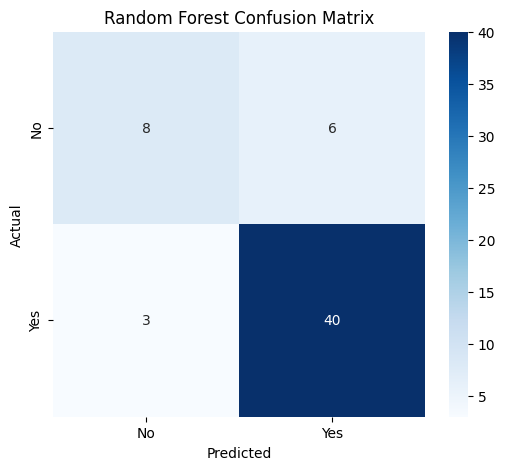

In [56]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["No", "Yes"],
    yticklabels=["No", "Yes"]
)

plt.title("Random Forest Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [57]:
from sklearn.metrics import precision_score, recall_score, f1_score

evaluation_results = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1-Score"],
    "Logistic Regression": [
        accuracy_score(y_test, y_pred_lr),
        precision_score(y_test, y_pred_lr, pos_label="Yes"),
        recall_score(y_test, y_pred_lr, pos_label="Yes"),
        f1_score(y_test, y_pred_lr, pos_label="Yes")
    ],
    "Random Forest": [
        accuracy_score(y_test, y_pred_rf),
        precision_score(y_test, y_pred_rf, pos_label="Yes"),
        recall_score(y_test, y_pred_rf, pos_label="Yes"),
        f1_score(y_test, y_pred_rf, pos_label="Yes")
    ]
})

evaluation_results

,Metric,Logistic Regression,Random Forest
0,Accuracy,0.842105,0.842105
1,Precision,0.869565,0.869565
2,Recall,0.930233,0.930233
3,F1-Score,0.898876,0.898876


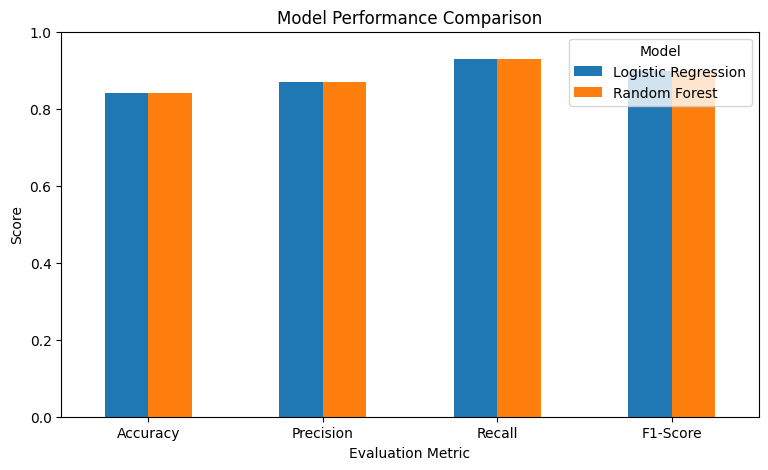

In [58]:
evaluation_results.set_index("Metric").plot(
    kind="bar",
    figsize=(9, 5)
)

plt.title("Model Performance Comparison")
plt.xlabel("Evaluation Metric")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.legend(title="Model")
plt.show()

## AI-Based Customer Prediction

The trained Random Forest model is used to predict whether a new customer
is likely to order food online based on demographic, socioeconomic,
customer-type, feedback, and geographic attributes.

In [59]:
sample_customer = pd.DataFrame({
    "Age": [25],
    "Gender": ["Male"],
    "Marital Status": ["Single"],
    "Occupation": ["Student"],
    "Monthly Income": ["No Income"],
    "Educational Qualifications": ["Graduate"],
    "Family size": [3],
    "Customer Type": ["Individual"],
    "latitude": [19.0760],
    "longitude": [72.8777],
    "Pin code": [400001],
    "Feedback": ["Positive"]
})

sample_customer

,Age,Gender,Marital Status,Occupation,Monthly Income,Educational Qualifications,Family size,Customer Type,latitude,longitude,Pin code,Feedback
0,25,Male,Single,Student,No Income,Graduate,3,Individual,19.076,72.8777,400001,Positive


In [60]:
prediction = rf_model.predict(sample_customer)

print("Predicted Online Food Ordering:", prediction[0])

Predicted Online Food Ordering: Yes


In [61]:
prediction_probability = rf_model.predict_proba(sample_customer)

probability_df = pd.DataFrame(
    prediction_probability,
    columns=rf_model.classes_
)

probability_df

,No,Yes
0,0.1,0.9


In [62]:
print("Prediction:", prediction[0])

for class_name, probability in zip(
    rf_model.classes_,
    prediction_probability[0]
):
    print(f"Probability of {class_name}: {probability:.2%}")

Prediction: Yes
Probability of No: 10.00%
Probability of Yes: 90.00%


## Feature Importance Analysis

Feature importance is used to identify which customer attributes contribute
most to the Random Forest model's predictions. This helps interpret the
machine-learning model beyond its prediction accuracy.

In [63]:
feature_names = rf_model.named_steps["preprocessor"].get_feature_names_out()

importances = rf_model.named_steps["classifier"].feature_importances_

feature_importance = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importances
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance.head(15)

,Feature,Importance
22,categorical__Feedback_Negative,0.138706
23,categorical__Feedback_Positive,0.113562
27,numeric__longitude,0.106914
26,numeric__latitude,0.098341
28,numeric__Pin code,0.093940
24,numeric__Age,0.086291
25,numeric__Family size,0.053906
4,categorical__Marital Status_Single,0.029352
8,categorical__Occupation_Student,0.022497
0,categorical__Gender_Female,0.018524


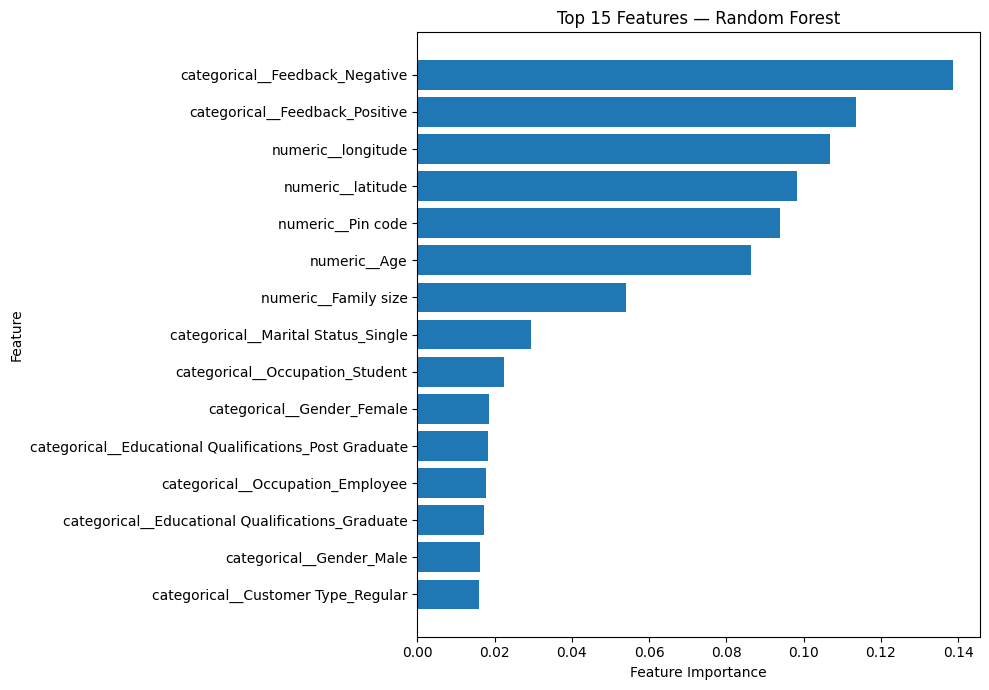

In [64]:
top_features = feature_importance.head(15).sort_values(
    by="Importance",
    ascending=True
)

plt.figure(figsize=(10, 7))

plt.barh(
    top_features["Feature"],
    top_features["Importance"]
)

plt.title("Top 15 Features — Random Forest")
plt.xlabel("Feature Importance")
plt.ylabel("Feature")

plt.tight_layout()
plt.show()

In [65]:
feature_importance.head(15)

,Feature,Importance
22,categorical__Feedback_Negative,0.138706
23,categorical__Feedback_Positive,0.113562
27,numeric__longitude,0.106914
26,numeric__latitude,0.098341
28,numeric__Pin code,0.093940
24,numeric__Age,0.086291
25,numeric__Family size,0.053906
4,categorical__Marital Status_Single,0.029352
8,categorical__Occupation_Student,0.022497
0,categorical__Gender_Female,0.018524


In [66]:
print("========== FINAL MODEL RESULTS ==========")

print("\nLogistic Regression Accuracy:")
print(f"{lr_accuracy:.4f}")

print("\nRandom Forest Accuracy:")
print(f"{rf_accuracy:.4f}")

print("\n========== RANDOM FOREST CLASSIFICATION REPORT ==========")
print(classification_report(y_test, y_pred_rf))

print("\n========== TOP 10 FEATURES ==========")
print(feature_importance.head(10).to_string(index=False))

print("\n========== SAMPLE CUSTOMER PREDICTION ==========")
print("Prediction:", prediction[0])

print("\nPrediction Probabilities:")
for class_name, probability in zip(
    rf_model.classes_,
    prediction_probability[0]
):
    print(f"{class_name}: {probability:.2%}")

========== FINAL MODEL RESULTS ==========

Logistic Regression Accuracy:
0.8421

Random Forest Accuracy:
0.8421

========== RANDOM FOREST CLASSIFICATION REPORT ==========
              precision    recall  f1-score   support

          No       0.73      0.57      0.64        14
         Yes       0.87      0.93      0.90        43

    accuracy                           0.84        57
   macro avg       0.80      0.75      0.77        57
weighted avg       0.83      0.84      0.84        57


========== TOP 10 FEATURES ==========
                           Feature  Importance
    categorical__Feedback_Negative    0.138706
    categorical__Feedback_Positive    0.113562
                numeric__longitude    0.106914
                 numeric__latitude    0.098341
                 numeric__Pin code    0.093940
                      numeric__Age    0.086291
              numeric__Family size    0.053906
categorical__Marital Status_Single    0.029352
   categorical__Occupation_Student    0.

## Key Findings

The analysis examined customer demographic, socioeconomic, educational,
family, customer-type, feedback, and geographic attributes in relation to
online food-ordering behavior.

Two classification algorithms, Logistic Regression and Random Forest, were
trained and evaluated using the same training and testing data.

The model evaluation considered accuracy, precision, recall, F1-score, and
confusion matrix results.

Feature importance from the Random Forest model was also examined to identify
the attributes that contributed most to its predictions.

The model was additionally tested on a sample customer record to demonstrate
how the trained system can generate an online food-ordering prediction.

## Project Limitations

1. The dataset contains a relatively small number of unique observations after
   duplicate removal.

2. The target variable is based on the available `Output` field and therefore
   reflects the characteristics of this dataset rather than all online food
   delivery customers.

3. Model performance may change when evaluated on a larger or different
   population.

4. Feature importance indicates model usefulness for prediction and should not
   be interpreted as proof of causal relationships.

5. The prediction system is intended as an educational machine-learning
   project and should not be treated as a production decision-making system.

In [ ]:
## Conclusion

This project demonstrated an end-to-end data analytics and machine-learning
workflow for analyzing online food delivery customer behavior.

The workflow included data loading, data-quality assessment, duplicate
handling, exploratory data analysis, feature preprocessing, classification
model development, model evaluation, customer prediction, and feature
importance analysis.

Logistic Regression and Random Forest were evaluated using multiple
classification metrics. The resulting model can be used to demonstrate how
customer attributes can be transformed into a machine-learning prediction.

The project provides practical experience in Python, Pandas, data
visualization, Scikit-learn, classification algorithms, model evaluation,
and basic AI-assisted predictive analytics.

In [68]:
print("========== REPORT RESULTS ==========")

print("\nDataset Shape:")
print(df.shape)

print("\nTarget Distribution:")
print(df["Output"].value_counts())

print("\nModel Comparison:")
print(model_comparison)

print("\nDetailed Evaluation:")
print(evaluation_results)

print("\nTop 10 Features:")
print(feature_importance.head(10).to_string(index=False))

print("\nSample Prediction:")
print("Prediction:", prediction[0])

print("\nPrediction Probabilities:")
for class_name, probability in zip(
    rf_model.classes_,
    prediction_probability[0]
):
    print(f"{class_name}: {probability:.2%}")

========== REPORT RESULTS ==========

Dataset Shape:
(285, 13)

Target Distribution:
Output
Yes    217
No      68
Name: count, dtype: int64

Model Comparison:
                 Model  Accuracy
0  Logistic Regression  0.842105
1        Random Forest  0.842105

Detailed Evaluation:
      Metric  Logistic Regression  Random Forest
0   Accuracy             0.842105       0.842105
1  Precision             0.869565       0.869565
2     Recall             0.930233       0.930233
3   F1-Score             0.898876       0.898876

Top 10 Features:
                           Feature  Importance
    categorical__Feedback_Negative    0.138706
    categorical__Feedback_Positive    0.113562
                numeric__longitude    0.106914
                 numeric__latitude    0.098341
                 numeric__Pin code    0.093940
                      numeric__Age    0.086291
              numeric__Family size    0.053906
categorical__Marital Status_Single    0.029352
   categorical__Occupation_Student